<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/Currency-Prediction-Project/LSTM_Currencies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [818]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

In [819]:
#loading data
data =pd.read_csv("/content/Foreign_Exchange_Rates.xls")
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [820]:
#dropping null values and converting timeseries to datetime
data.dropna()
data['Time Serie'] = pd.to_datetime(data['Time Serie'], format='%d-%m-%Y')

In [821]:
#Pre-processing
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [822]:
# drop unnamed columns
data.drop(columns=['Unnamed: 24', 'Unnamed: 0'])

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,43.55,...,1.6563,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97
1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,1.6535,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13
2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,43.55,...,1.656,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1
3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,43.55,...,1.6655,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62
4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,43.55,...,1.6625,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5212,2019-12-25,ND,ND,ND,ND,ND,ND,ND,ND,ND,...,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
5213,2019-12-26,1.4411,0.9007,1.5002,0.7688,4.0602,1.3124,6.9949,7.788,71.28,...,1.354,6.7295,109.67,4.1337,8.8799,9.4108,181.3,0.9808,30.11,30.15
5214,2019-12-27,1.4331,0.8949,1.4919,0.7639,4.0507,1.3073,6.9954,7.7874,71.45,...,1.352,6.6829,109.47,4.126,8.8291,9.3405,181.35,0.9741,30.09,30.14
5215,2019-12-30,1.4278,0.8915,1.4846,0.761,4.0152,1.3058,6.9864,7.7857,71.3,...,1.3483,6.6589,108.85,4.1053,8.7839,9.3145,181.6,0.9677,30.04,29.94


In [823]:
#batch converting column objects to float types
rates = data.drop(columns=['Unnamed: 24', 'Unnamed: 0'])

for col in rates.columns:
    rates[col] = pd.to_numeric(rates[col], errors='coerce')

    print(rates)
print(rates.info())

               Time Serie AUSTRALIA - AUSTRALIAN DOLLAR/US$  \
0      946857600000000000                            1.5172   
1      946944000000000000                            1.5239   
2      947030400000000000                            1.5267   
3      947116800000000000                            1.5291   
4      947203200000000000                            1.5272   
...                   ...                               ...   
5212  1577232000000000000                                ND   
5213  1577318400000000000                            1.4411   
5214  1577404800000000000                            1.4331   
5215  1577664000000000000                            1.4278   
5216  1577750400000000000                            1.4225   

     EURO AREA - EURO/US$ NEW ZEALAND - NEW ZELAND DOLLAR/US$  \
0                  0.9847                              1.9033   
1                    0.97                              1.9238   
2                  0.9676                       

In [824]:
#forward/backward fill to correct NaN anomalies

rates.fillna(rates.ffill(), inplace=True)

In [825]:
#converting time feature to datetime again with newly converted data
rates['Time Serie'] = pd.to_datetime(rates['Time Serie'], format='mixed')
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5217 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   float64       
 2   EURO AREA - EURO/US$                       5217 non-null   float64       
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   float64       
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   float64       
 5   BRAZIL - REAL/US$                          5217 non-null   float64       
 6   CANADA - CANADIAN DOLLAR/US$               5217 non-null   float64       
 7   CHINA - YUAN/US$                           5217 non-null   float64       
 8   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   float64       
 9   INDIA - INDIAN RUPE

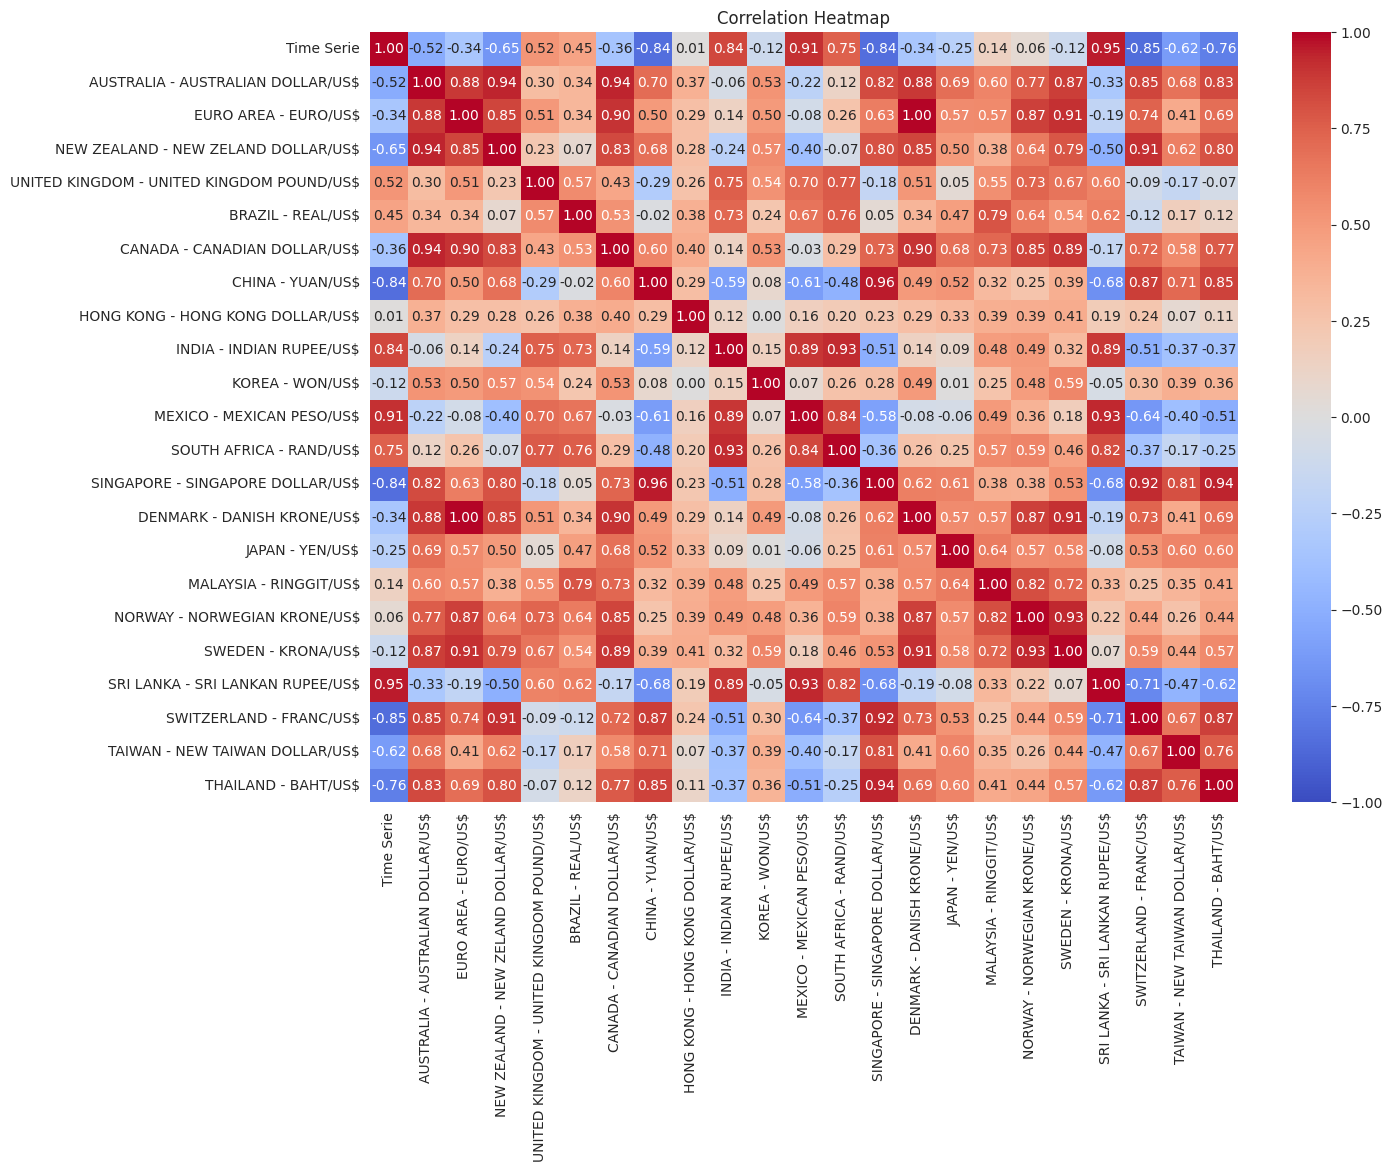

In [826]:
#EDA vizualisations:
#correlation matrix

corr_matrix = rates.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [827]:
rates.describe()

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
count,5217,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,...,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000
mean,2009-12-31 09:36:19.873490688,1.332284,0.844061,1.543651,0.640725,2.550569,1.230577,7.199286,7.782593,52.759603,...,1.480183,6.287160,106.592321,3.651972,7.078344,7.901722,119.200501,1.150089,31.766274,35.519478
min,2000-01-03 00:00:00,0.906900,0.624600,1.134600,0.473800,1.537500,0.916800,6.040200,7.708500,38.480000,...,1.200700,4.660500,75.720000,2.937000,4.946700,5.834600,72.300000,0.729600,28.500000,28.600000
25%,2004-12-31 00:00:00,1.115800,0.751100,1.323600,0.587900,1.946000,1.056000,6.475800,7.756300,45.270000,...,1.342600,5.594500,100.080000,3.292000,5.998800,6.853000,100.400000,0.966800,30.350000,31.780000
50%,2009-12-31 00:00:00,1.311500,0.815800,1.442600,0.636600,2.331000,1.237200,6.859700,7.780600,48.110000,...,1.408400,6.074000,109.060000,3.800000,6.786000,7.751000,112.350000,1.038600,31.730000,34.000000
75%,2014-12-31 00:00:00,1.430600,0.900300,1.591100,0.692400,3.132000,1.335700,8.276500,7.799800,62.470000,...,1.678700,6.715300,116.820000,3.800000,8.281300,8.747400,132.800000,1.268700,32.980000,39.410000
max,2019-12-31 00:00:00,2.071300,1.209200,2.551000,0.828700,4.259400,1.612800,8.280000,7.849900,74.330000,...,1.854000,9.005000,134.770000,4.496000,9.589000,11.027000,182.800000,1.825000,35.210000,45.820000
std,NaN,0.269792,0.126685,0.337116,0.082641,0.725318,0.182147,0.819876,0.027558,9.694685,...,0.188831,0.942385,13.221191,0.379180,1.227016,1.201698,25.409982,0.248856,1.670693,4.562211


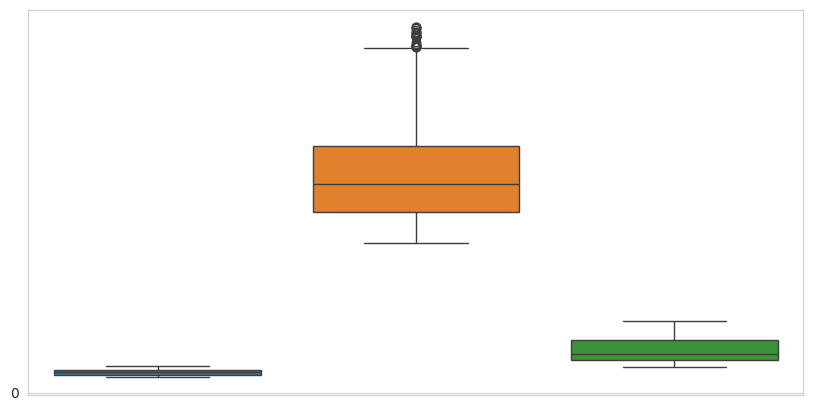

In [828]:
#box plots
## needs resizing
#individual plots
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize =(10,5))
g = sns.boxplot(data=rates[['CANADA - CANADIAN DOLLAR/US$', 'MEXICO - MEXICAN PESO/US$', 'BRAZIL - REAL/US$']])

xvalues = []
plt.xticks(np.arange(3), xvalues)

plt.yticks(np.arange(0,0.3))


plt.show()

In [829]:
#LSTM MODEL - train test split

def Sequential_Input_LSTM(rates, input_sequence):
    rates_np = rates.to_numpy()
    X = []
    y = []

    for i in range(len(rates_np) - input_sequence):
        row = [a for a in rates_np[i:i + input_sequence]]
        X.append(row)
        label = rates_np[i + input_sequence]
        y.append(label)

    return np.array(X), np.array(y)

In [830]:
n_input = 10      # number of historical inputs to be used for forecasting the future time series
#edit
# Select a single currency for the model, ensuring it remains a DataFrame
rates_min_model_data = rates[['THAILAND - BAHT/US$']]

X, y = Sequential_Input_LSTM(rates_min_model_data, n_input)

In [831]:
X.shape, y.shape

((5207, 10, 1), (5207, 1))

In [832]:
# Training data
X_train, y_train = X[:1400], y[:1400]

# Validation data
X_val, y_val = X[1400:1600], y[1400:1600]

# Test data
X_test, y_test = X[1600:], y[1600:]

In [833]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [834]:
X_train.shape, y_train.shape

((4165, 10, 1), (4165, 1))

In [835]:
X_val.shape, y_val.shape

((200, 10, 1), (200, 1))

In [836]:
X_test.shape, y_test.shape

((1042, 10, 1), (1042, 1))

In [837]:
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import BatchNormalization, InputLayer, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam

In [838]:
#building model
n_features = 1 # number of input variables used for forecast (here, 1 for selected currency)

model1 = Sequential([
    InputLayer(input_shape=(n_input, n_features)), # Define input shape for the model
    BatchNormalization(), # BatchNormalization can follow the InputLayer
    LSTM(100, return_sequences = True),
    LSTM(100, return_sequences = True),
    LSTM(50),
    Dense(1, activation = 'relu'),
    Dense(1, activation = 'linear')
])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_28          │ (None, 10, 1)          │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_84 (LSTM)                  │ (None, 10, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_85 (LSTM)                  │ (None, 10, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_86 (LSTM)                  │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,457 (591.63 KB)

 Trainable params: 151,455 (591.62 KB)

 Non-trainable params: 2 (8.00 B)

In [839]:
early_stop = EarlyStopping(monitor = 'val_loss', patience = 2)

model1.compile(loss = MeanSquaredError(), optimizer = Adam(learning_rate = 0.0001), metrics = [RootMeanSquaredError()])

In [808]:
#training model
model1.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = 50, callbacks = [early_stop])

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 1278.6442 - root_mean_squared_error: 35.7581 - val_loss: 1658.4474 - val_root_mean_squared_error: 40.7240
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 1277.7118 - root_mean_squared_error: 35.7451 - val_loss: 1657.3812 - val_root_mean_squared_error: 40.7109
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1276.7832 - root_mean_squared_error: 35.7321 - val_loss: 1656.3159 - val_root_mean_squared_error: 40.6979
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 1275.8561 - root_mean_squared_error: 35.7191 - val_loss: 1655.2507 - val_root_mean_squared_error: 40.6848
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 1274.9287 - root_mean_squared_error: 35.7061 - val_loss: 1654.1874 - val_root_mean_squared_error: 40.6717
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 1274.0021 - root_mean_squared_error: 35.6932 - val_loss: 1653.1227 - val_root_mean_squared_error: 40.658

In [809]:
losses_df1 = pd.DataFrame(model1.history.history)
losses_df1

,loss,root_mean_squared_error,val_loss,val_root_mean_squared_error
0,1278.644165,35.758133,1658.447388,40.724041
1,1277.711792,35.745094,1657.381226,40.710949
2,1276.783203,35.732101,1656.315918,40.697861
3,1275.856079,35.719128,1655.250732,40.684772
4,1274.928711,35.706142,1654.187378,40.671703
5,1274.002075,35.693165,1653.122681,40.658611
6,1273.076050,35.680191,1652.059814,40.645538
7,1272.150024,35.667213,1650.995972,40.632450
8,1271.224121,35.654228,1649.933228,40.619370
9,1270.299438,35.641262,1648.870483,40.606285


In [810]:
scores = model1.evaluate(X_test, y_test, verbose=0)
print("%s: %.2f%%" % (model1.metrics_names[0], scores[0]*100))
print("%s: %.2f%%" % ('RootMeanSquaredError', scores[1]*100))

loss: 124852.93%
RootMeanSquaredError: 3533.45%


In [811]:
test_predictions1 = model1.predict(X_test).flatten()
test_predictions1

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


array([0.6534309, 0.6534309, 0.6534309, ..., 0.6534309, 0.6534309,
       0.6534309], dtype=float32)

In [812]:
len(X_test), len(test_predictions1)

(1042, 1042)

In [813]:
test_predictions1.ndim

1

In [814]:
X_test_list = []
for i in range(len(X_test)):
    X_test_list.append(X_test[i][0])

len(X_test_list)

1042

In [815]:
test_predictions_df1 = pd.DataFrame({'X_test':list(X_test_list), 'LSTM Prediction':list(test_predictions1)})
len(test_predictions_df1)

test_predictions_df1.head()

,X_test,LSTM Prediction
0,[44.77],0.653431
1,[42.79],0.653431
2,[33.11],0.653431
3,[32.44],0.653431
4,[33.1],0.653431


In [816]:
y_predicted = test_predictions_df1['LSTM Prediction']

mae_metric = MeanAbsoluteError()
mae_metric.update_state(y_test, y_predicted)
mae_result = mae_metric.result().numpy()

print(f"Test MAE: {mae_result}")

Test MAE: 35.02714157104492


In [817]:
def calculate_mape(actual, predicted):
    absolute_errors = np.abs(actual - predicted)
    percentage_errors = absolute_errors / actual
    mape = np.mean(percentage_errors) * 100
    return mape

mape = calculate_mape(y_predicted, y_test.flatten())
print("MAPE:", mape, "%")

MAPE: 5360.496612211237 %
